# Comparing All Three Attacks at Matched Settings

`attacks/whitebox/01_FGSM.ipynb`, `02_PGD.ipynb` and `attacks/blackbox/01_WaveformSquareAttack.ipynb` each evaluate on the same 10 hand-picked clips, one per class, but never against each other at a single matched epsilon in one place. This notebook closes that gap: FGSM, PGD, and Waveform Square Attack, run against a larger, real sample of test clips (several per class, not one), reporting Attack Success Rate, SNR, and query cost side by side, the audio equivalent of `adversarial_attacks_nlp/robustness_evaluation/01_attack_comparison.ipynb` and the whitebox-vs-blackbox comparisons throughout the vision repo.

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import soundfile as sf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

torch.manual_seed(0)
np.random.seed(0)

def _load_wav(path, frame_offset=0, num_frames=-1, normalize=True, channels_first=True, format=None, buffer_size=4096, backend=None):
    """Replaces torchaudio's TorchCodec-based loader (needs a separately installed FFmpeg, not
    available here) with soundfile, which reads WAV directly with no extra system dependencies."""
    data, sample_rate = sf.read(path, dtype='float32')
    waveform = torch.from_numpy(data)
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(1)
    if channels_first:
        waveform = waveform.transpose(0, 1)
    return waveform, sample_rate

torchaudio.load = _load_wav

### Setup: Model and a Real Sample of Test Clips
Same `KeywordCNN` and log-mel front end trained in `models/01_train_keyword_spotter.ipynb`. Unlike the individual attack notebooks, which each attack one clip per class, this one draws `CLIPS_PER_CLASS` real clips per class from the held-out test split, so the comparison below reflects a real sample rather than three cherry-picked examples.

In [2]:
LABELS = ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go']
LABEL_TO_IDX = {label: i for i, label in enumerate(LABELS)}
SAMPLE_RATE = 16000
CLIPS_PER_CLASS = 5  # -> up to 50 clips total, vs. the 10 (1/class) used by the individual attack notebooks

mel_spectrogram = torchaudio.transforms.MelSpectrogram(sample_rate=SAMPLE_RATE, n_mels=64, n_fft=400, hop_length=160)
to_db = torchaudio.transforms.AmplitudeToDB()

def waveform_to_spectrogram(waveform):
    return to_db(mel_spectrogram(waveform))

class KeywordCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, spectrogram):
        x = self.pool(F.relu(self.bn1(self.conv1(spectrogram))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.global_pool(x).flatten(1)
        return self.fc(x)

model = KeywordCNN(num_classes=len(LABELS))
model.load_state_dict(torch.load('../models/keyword_spotter.pth', map_location='cpu'))
model.eval()
print("Loaded keyword_spotter.pth")

os.makedirs('../models/speech_commands_data', exist_ok=True)  # SPEECHCOMMANDS(download=True) expects this to already exist
test_data = torchaudio.datasets.SPEECHCOMMANDS(root='../models/speech_commands_data', download=True, subset='testing')

def pad_or_trim(waveform):
    if waveform.shape[1] < SAMPLE_RATE:
        return F.pad(waveform, (0, SAMPLE_RATE - waveform.shape[1]))
    return waveform[:, :SAMPLE_RATE]

per_class_counts = {label: 0 for label in LABELS}
sample_clips = []  # list of (label, waveform)
for i in range(len(test_data)):
    waveform, sr, label, *_ = test_data[i]
    if label in LABEL_TO_IDX and per_class_counts[label] < CLIPS_PER_CLASS:
        sample_clips.append((label, pad_or_trim(waveform)))
        per_class_counts[label] += 1
    if all(c >= CLIPS_PER_CLASS for c in per_class_counts.values()):
        break

print(f"Collected {len(sample_clips)} clips across {len(LABELS)} classes ({CLIPS_PER_CLASS}/class target)")

Loaded keyword_spotter.pth


Collected 50 clips across 10 classes (5/class target)


### The Three Attacks
`fgsm_attack` and `pgd_attack` are identical to `attacks/whitebox/01_FGSM.ipynb`/`02_PGD.ipynb`. `waveform_square_attack` is the same greedy random-segment search as `attacks/blackbox/01_WaveformSquareAttack.ipynb`, extended here to also return the number of queries actually used, so query cost can be reported alongside ASR and SNR in the summary table below.

In [3]:
def fgsm_attack(waveform, true_label_idx, epsilon):
    waveform = waveform.clone().requires_grad_(True)
    logits = model(waveform_to_spectrogram(waveform.unsqueeze(0)))
    loss = F.cross_entropy(logits, torch.tensor([true_label_idx]))
    loss.backward()
    adv_waveform = waveform + epsilon * waveform.grad.sign()
    return torch.clamp(adv_waveform.detach(), -1.0, 1.0)

def pgd_attack(waveform, true_label_idx, epsilon, iters=10):
    alpha = epsilon / (iters / 2.0)
    adv_waveform = waveform.clone()
    for _ in range(iters):
        adv_waveform = adv_waveform.clone().requires_grad_(True)
        logits = model(waveform_to_spectrogram(adv_waveform.unsqueeze(0)))
        loss = F.cross_entropy(logits, torch.tensor([true_label_idx]))
        loss.backward()
        adv_waveform = adv_waveform + alpha * adv_waveform.grad.sign()
        perturbation = torch.clamp(adv_waveform - waveform, -epsilon, epsilon)
        adv_waveform = torch.clamp(waveform + perturbation, -1.0, 1.0).detach()
    return adv_waveform

@torch.no_grad()
def true_class_prob(waveform, true_label_idx):
    logits = model(waveform_to_spectrogram(waveform.unsqueeze(0)))
    probs = F.softmax(logits, dim=-1)[0]
    return float(probs[true_label_idx]), int(torch.argmax(probs))

def waveform_square_attack(waveform, true_label_idx, epsilon, query_budget):
    adv_waveform = waveform.clone()
    best_prob, current_pred = true_class_prob(adv_waveform, true_label_idx)
    length = waveform.shape[1]
    queries_used = 1

    for _ in range(query_budget):
        if current_pred != true_label_idx:
            break
        seg_len = int(length * np.random.uniform(0.05, 0.10))
        start = np.random.randint(0, length - seg_len)
        sign = np.random.choice([-1.0, 1.0])

        candidate = adv_waveform.clone()
        candidate[:, start:start + seg_len] = torch.clamp(
            waveform[:, start:start + seg_len] + sign * epsilon, -1.0, 1.0)

        candidate_prob, candidate_pred = true_class_prob(candidate, true_label_idx)
        queries_used += 1
        if candidate_prob < best_prob:
            adv_waveform, best_prob, current_pred = candidate, candidate_prob, candidate_pred

    return adv_waveform, current_pred != true_label_idx, queries_used

def snr_db(clean, adv):
    noise_power = float(torch.sum((adv - clean) ** 2))
    signal_power = float(torch.sum(clean ** 2))
    if noise_power == 0:
        return float('inf')
    return 10 * torch.log10(torch.tensor(signal_power / noise_power)).item()

### Evaluation
One matched epsilon for FGSM/PGD ($\varepsilon = 0.02$, moderate on the sweep in `01_FGSM.ipynb`, where FGSM alone reaches 62.5% ASR, leaving room to see whether PGD does meaningfully better at the *same* budget) and one query budget for Square Attack (`SQUARE_QUERY_BUDGET = 50`, comparable order of magnitude to the perturbation budget the gradient attacks get to use in 10 PGD steps). Only clips the model already classifies correctly are attacked, the same "robust accuracy" convention used throughout this repo family.

In [4]:
EPSILON = 0.02
PGD_ITERS = 10
SQUARE_QUERY_BUDGET = 50

rows = []
for label, waveform in sample_clips:
    true_idx = LABEL_TO_IDX[label]
    orig_prob, orig_pred = true_class_prob(waveform, true_idx)
    if orig_pred != true_idx:
        continue

    start = time.time()
    adv_fgsm = fgsm_attack(waveform, true_idx, EPSILON)
    _, fgsm_pred = true_class_prob(adv_fgsm, true_idx)
    fgsm_time = time.time() - start
    rows.append({
        'Attack': 'FGSM', 'Label': label, 'Success': fgsm_pred != true_idx,
        'SNR_dB': snr_db(waveform, adv_fgsm), 'Queries': None, 'Time_Sec': fgsm_time,
    })

    start = time.time()
    adv_pgd = pgd_attack(waveform, true_idx, EPSILON, iters=PGD_ITERS)
    _, pgd_pred = true_class_prob(adv_pgd, true_idx)
    pgd_time = time.time() - start
    rows.append({
        'Attack': 'PGD', 'Label': label, 'Success': pgd_pred != true_idx,
        'SNR_dB': snr_db(waveform, adv_pgd), 'Queries': None, 'Time_Sec': pgd_time,
    })

    start = time.time()
    adv_square, square_success, queries_used = waveform_square_attack(waveform, true_idx, EPSILON, SQUARE_QUERY_BUDGET)
    square_time = time.time() - start
    rows.append({
        'Attack': 'Square Attack', 'Label': label, 'Success': square_success,
        'SNR_dB': snr_db(waveform, adv_square), 'Queries': queries_used, 'Time_Sec': square_time,
    })

results_df = pd.DataFrame(rows)
results_df.to_csv('attack_comparison.csv', index=False)
print(f"Evaluated {results_df['Label'].nunique()} classes, {len(results_df) // 3} clips already correctly classified")

Evaluated 10 classes, 27 clips already correctly classified


### Summary: ASR, Imperceptibility, and Cost Side by Side
The same three-way comparison vision makes between FGSM/PGD and Square Attack, and NLP makes between HotFlip and Synonym Substitution, now for audio: does spending more (gradient access, iterations, or queries) buy a proportionally better attack, at a matched perturbation budget.

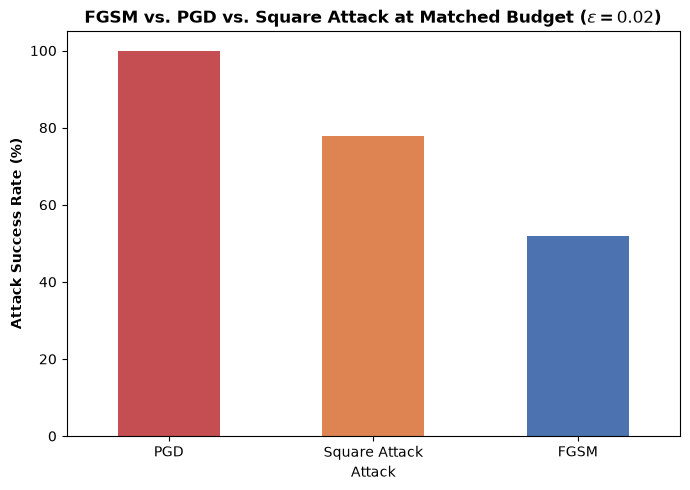

,ASR,Avg_SNR_dB,Avg_Queries,Avg_Time_Sec,N
Attack,,,,,
PGD,100.0,16.95,NaN,0.058,27
Square Attack,77.8,17.83,18.740741,0.044,27
FGSM,51.9,12.05,NaN,0.008,27


In [5]:
summary = results_df.groupby('Attack').agg(
    ASR=('Success', 'mean'),
    Avg_SNR_dB=('SNR_dB', 'mean'),
    Avg_Queries=('Queries', 'mean'),
    Avg_Time_Sec=('Time_Sec', 'mean'),
    N=('Success', 'count'),
).sort_values('ASR', ascending=False)
summary['ASR'] = (summary['ASR'] * 100).round(1)
summary['Avg_SNR_dB'] = summary['Avg_SNR_dB'].round(2)
summary['Avg_Time_Sec'] = summary['Avg_Time_Sec'].round(3)

ax = summary['ASR'].plot(kind='bar', figsize=(7, 5), color=['#C44E52', '#DD8452', '#4C72B0'])
ax.set_ylabel('Attack Success Rate (%)', fontweight='bold')
ax.set_title(f'FGSM vs. PGD vs. Square Attack at Matched Budget ($\\varepsilon={EPSILON}$)', fontweight='bold')
ax.set_ylim(0, 105)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

summary